<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_14_Linear_Models_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 14 — Linear Models and Deep Neural Networks

*Based on "Time Series Forecasting in Python" by Marco Peixeiro, Chapter 14.*

In Chapter 13 we built the **`DataWindow` infrastructure** and three **baseline models** (single-step last-value, multi-step last-value, multi-step repeat, multi-output last-value). Those baselines have zero trainable parameters — they just slice the input and return it as the prediction. They establish the *floor* that trained models must beat.

This chapter takes the first real step into deep learning. We build:

1. **Linear models** — the simplest neural architecture, just one `Dense` layer with no hidden layer or activation function. Mathematically equivalent to a multivariate linear regression.
2. **Deep neural networks (DNNs)** — two hidden layers of $64$ neurons each with **ReLU** activation, ending in a linear output layer. The added depth lets the network model *nonlinear* relationships between features and targets.

For each architecture we implement three variants — **single-step**, **multi-step**, and **multi-output** — using the same `DataWindow` instances from Ch 13. The result: six trained models whose MAEs go directly into the same `val_performance` / `performance` dictionaries we started filling in Ch 13. Comparison plots at the end will show how each architecture stacks up against the baselines.

**Key questions this chapter answers**

- Can a one-layer linear model beat the naive baselines?
- How much extra performance does adding two hidden layers and ReLU activation buy us?
- Where does the dense network struggle (or shine) most: single-step, multi-step, or multi-output?

**The architecture progression**

| Chapter | Model | Hidden layers | Activation | Trainable params (single-step) |
|---|---|---|---|---|
| 13 | Baseline | — | — | $0$ |
| 14 | Linear | $0$ | none | $6$ ($5$ weights + 1 bias) |
| 14 | Dense | $2 \times 64$ | ReLU | $\approx 4{,}545$ |
| 15+ | LSTM, CNN, Transformer | many | various | $10^4 \sim 10^6$ |

We are climbing a complexity ladder. Each rung must justify itself with better test MAE; otherwise, stop climbing and ship the lower-complexity model.

## Setup

We re-import everything from Chapter 13 — same libraries, same random seeds, same data. The notebook is self-contained; if you've already run Chapter 13's notebook you can skip the setup and load directly from your existing namespace.

In [1]:
# Install required packages (Colab already has tensorflow)
!pip install -q tensorflow pandas numpy matplotlib

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF info logs

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

# Reproducibility - critical because training uses random initialization
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.20.0


**Why `tf.random.set_seed(42)` matters here.** Unlike Ch 13's baselines (which have no trainable parameters and produce identical results every run), training a neural network involves:

- Random weight initialization (Glorot uniform by default),
- Random shuffling of training batches,
- Numerical noise from floating-point arithmetic.

Without a fixed seed, two runs of the same code would produce slightly different MAEs — by a few thousandths at minimum. The seed lets us reproduce the book's results to within numerical tolerance.

## Reloading the data and `DataWindow` class

We reload the same three preprocessed datasets and re-instantiate the `DataWindow` class verbatim from Chapter 13. If you ran Chapter 13's notebook in the same Colab session, the class and dataframes are already available — skip ahead to the section "Stage 1: Linear models."

This redundancy is intentional: each chapter notebook should be runnable end-to-end on its own.

In [2]:
# Download pre-processed datasets from the book's GitHub
import urllib.request
base_url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data'

for fname in ['train.csv', 'val.csv', 'test.csv']:
    urllib.request.urlretrieve(f'{base_url}/{fname}', fname)

train_df = pd.read_csv('train.csv', index_col=0)
val_df   = pd.read_csv('val.csv',   index_col=0)
test_df  = pd.read_csv('test.csv',  index_col=0)

print(f'Train shape: {train_df.shape}')
print(f'Val shape:   {val_df.shape}')
print(f'Test shape:  {test_df.shape}')

Train shape: (12285, 5)
Val shape:   (3510, 5)
Test shape:  (1756, 5)


Dataset shapes match Chapter 13: $12{,}285$ training rows, $3{,}510$ validation rows, $1{,}756$ test rows. Five columns: `temp`, `clouds_all`, `traffic_volume`, `day_sin`, `day_cos`.

In [3]:
class DataWindow():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None):
        self.train_df = train_df
        self.val_df   = val_df
        self.test_df  = test_df

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_to_inputs_labels(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def plot(self, model=None, plot_col='traffic_volume', max_subplots=3):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f'{plot_col} [scaled]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Inputs', marker='.', zorder=-10)
            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index
            if label_col_index is None:
                continue
            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', marker='s', label='Labels', c='green', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions', c='red', s=64)
            if n == 0:
                plt.legend()
        plt.xlabel('Time (h)')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data, targets=None,
            sequence_length=self.total_window_size, sequence_stride=1,
            shuffle=True, batch_size=32
        )
        return ds.map(self.split_to_inputs_labels)

    @property
    def train(self): return self.make_dataset(self.train_df)
    @property
    def val(self):   return self.make_dataset(self.val_df)
    @property
    def test(self):  return self.make_dataset(self.test_df)

    @property
    def sample_batch(self):
        result = getattr(self, '_sample_batch', None)
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result
        return result

print('DataWindow class defined.')

DataWindow class defined.


### Re-instantiate the windows and re-run baselines

We need the **same three windows** as Chapter 13:

- `single_step_window` — for training single-step and multi-output models ($1 \to 1$, shift $= 1$)
- `wide_window` — for visualizing single-step predictions ($24 \to 24$, shift $= 1$)
- `multi_window` — for training and visualizing multi-step models ($24 \to 24$, shift $= 24$)
- `mo_single_step_window` / `mo_wide_window` — the same shapes but with two label columns (`temp`, `traffic_volume`) for multi-output models

We also re-run the baseline models from Chapter 13 so their MAEs populate the `val_performance` / `performance` dictionaries. Without these dictionaries pre-filled, the final comparison plots wouldn't include baselines.

In [4]:
# === Single-step + multi-output windows ===
single_step_window    = DataWindow(input_width=1,  label_width=1,  shift=1,
                                   label_columns=['traffic_volume'])
wide_window           = DataWindow(input_width=24, label_width=24, shift=1,
                                   label_columns=['traffic_volume'])

multi_window          = DataWindow(input_width=24, label_width=24, shift=24,
                                   label_columns=['traffic_volume'])

mo_single_step_window = DataWindow(input_width=1,  label_width=1,  shift=1,
                                   label_columns=['temp', 'traffic_volume'])
mo_wide_window        = DataWindow(input_width=24, label_width=24, shift=1,
                                   label_columns=['temp', 'traffic_volume'])

column_indices = {name: i for i, name in enumerate(train_df.columns)}
print(f'Column indices: {column_indices}')

Column indices: {'temp': 0, 'clouds_all': 1, 'traffic_volume': 2, 'day_sin': 3, 'day_cos': 4}


All windows configured. The column-indices dict tells us `traffic_volume` sits at column $2$ and `temp` at column $0$ — same as Chapter 13.

In [5]:
# === Baseline classes (verbatim from Chapter 13) ===
class Baseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return inputs
        elif isinstance(self.label_index, list):
            tensors = []
            for index in self.label_index:
                result = inputs[:, :, index]
                result = result[:, :, tf.newaxis]
                tensors.append(result)
            return tf.concat(tensors, axis=-1)
        result = inputs[:, :, self.label_index]
        return result[:, :, tf.newaxis]


class MultiStepLastBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return tf.tile(inputs[:, -1:, :], [1, 24, 1])
        return tf.tile(inputs[:, -1:, self.label_index:], [1, 24, 1])


class RepeatBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        return inputs[:, :, self.label_index:]


# === Initialize performance dictionaries and evaluate all baselines ===
val_performance, performance = {}, {}
ms_val_performance, ms_performance = {}, {}
mo_val_performance, mo_performance = {}, {}

# Single-step baseline
baseline_last = Baseline(label_index=column_indices['traffic_volume'])
baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
val_performance['Baseline - Last'] = baseline_last.evaluate(single_step_window.val, verbose=0)
performance['Baseline - Last']     = baseline_last.evaluate(single_step_window.test, verbose=0)

# Multi-step baselines
ms_baseline_last = MultiStepLastBaseline(label_index=column_indices['traffic_volume'])
ms_baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
ms_val_performance['Baseline - Last'] = ms_baseline_last.evaluate(multi_window.val, verbose=0)
ms_performance['Baseline - Last']     = ms_baseline_last.evaluate(multi_window.test, verbose=0)

ms_baseline_repeat = RepeatBaseline(label_index=column_indices['traffic_volume'])
ms_baseline_repeat.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
ms_val_performance['Baseline - Repeat'] = ms_baseline_repeat.evaluate(multi_window.val, verbose=0)
ms_performance['Baseline - Repeat']     = ms_baseline_repeat.evaluate(multi_window.test, verbose=0)

# Multi-output baseline
mo_baseline_last = Baseline(label_index=[0, 2])
mo_baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
mo_val_performance['Baseline - Last'] = mo_baseline_last.evaluate(mo_wide_window.val, verbose=0)
mo_performance['Baseline - Last']     = mo_baseline_last.evaluate(mo_wide_window.test, verbose=0)

print(f"Single-step  Baseline test MAE: {performance['Baseline - Last'][1]:.4f}")
print(f"Multi-step   Last test MAE:     {ms_performance['Baseline - Last'][1]:.4f}")
print(f"Multi-step   Repeat test MAE:   {ms_performance['Baseline - Repeat'][1]:.4f}")
print(f"Multi-output Baseline test MAE: {mo_performance['Baseline - Last'][1]:.4f}")

Single-step  Baseline test MAE: 0.0813
Multi-step   Last test MAE:     0.3473
Multi-step   Repeat test MAE:   0.3413
Multi-output Baseline test MAE: 0.0471


The four baseline floors from Chapter 13 are now reloaded into the performance dictionaries:

| Setup | Test MAE |
|---|---|
| Single-step Baseline | $0.0813$ |
| Multi-step Last | $0.3473$ |
| Multi-step Repeat | $0.3413$ |
| Multi-output Baseline | $0.0471$ |

Every trained model we build in this chapter must beat these to justify its complexity.

## The training helper: `compile_and_fit`

Every trained model in this chapter — and every model in the deep-learning chapters that follow — goes through the same training routine: compile with MSE loss and Adam optimizer, fit on the training set, validate on the validation set, and stop early if validation loss stagnates. We wrap this in a single helper function.

In [6]:
def compile_and_fit(model, window, patience=3, max_epochs=50):
    # Stop training if val_loss does not decrease for `patience` consecutive epochs
    early_stopping = EarlyStopping(monitor='val_loss',
                                   patience=patience,
                                   mode='min')

    model.compile(loss=MeanSquaredError(),
                  optimizer=Adam(),
                  metrics=[MeanAbsoluteError()])

    history = model.fit(window.train,
                        epochs=max_epochs,
                        validation_data=window.val,
                        callbacks=[early_stopping],
                        verbose=0)  # silent fitting; we report results separately
    return history

print('compile_and_fit helper ready.')

compile_and_fit helper ready.


**Three design choices** in this helper deserve attention:

1. **`MSE` for loss, `MAE` for metric.** Same pairing as Ch 13. MSE drives the gradient because squaring punishes large errors heavily (the optimizer focuses on outliers). MAE is reported because it's interpretable in the original scale.
2. **`Adam` optimizer.** Adaptive Moment Estimation. Maintains per-parameter learning rates based on running averages of recent gradients (momentum) and squared gradients (variance scaling). The update rule is roughly:
$$\theta_{t+1} = \theta_t - \alpha \cdot \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}$$
where $\hat m_t$ is the bias-corrected mean and $\hat v_t$ is the bias-corrected variance of recent gradients. Default $\alpha = 0.001$. Adam handles ill-conditioned losses gracefully without needing manual tuning — which is why it's the default choice across nearly all of modern deep learning.
3. **Early stopping with `patience=3`.** Training halts when validation loss fails to improve for 3 consecutive epochs. This is the **deep-learning analog of AIC's $2k$ penalty** — it prevents the model from continuing to over-fit the training set after it has stopped generalizing. With `max_epochs=50` as a safety ceiling, most models converge in $10$–$25$ epochs.

A single `compile_and_fit` call replaces the verbose `model.compile(...) → model.fit(...) → callback wiring` pattern that would otherwise repeat six times in this chapter.

## Stage 1: Linear models

A **linear model** is the simplest neural architecture: a single `Dense` layer with no activation function. For our single-step problem with $5$ input features, the model computes:

$$\hat{y}_{t+1} = w_1 \cdot \text{temp}_t + w_2 \cdot \text{clouds}_t + w_3 \cdot \text{traffic}_t + w_4 \cdot \text{day\_sin}_t + w_5 \cdot \text{day\_cos}_t + b$$

That's $5$ weights and $1$ bias = $\mathbf{6}$ trainable parameters. This is **mathematically equivalent to multivariate linear regression** — but expressed in Keras for two practical reasons:

1. It plugs into our `DataWindow` pipeline like any other Keras model.
2. It serves as a stepping stone: if the linear model already beats the baseline, we know the features carry linear signal. If a dense network then beats the linear model, we know there's *additional* nonlinear signal worth capturing.

We build linear models for all three setups: single-step, multi-step, multi-output.

### 14.1.1 Single-step linear model

In [7]:
linear = Sequential([
    Dense(units=1)
])

history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val, verbose=0)
performance['Linear']     = linear.evaluate(single_step_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Linear single-step  Val MAE: {val_performance['Linear'][1]:.4f}")
print(f"Linear single-step  Test MAE: {performance['Linear'][1]:.4f}")

Trained for 19 epochs
Final train loss: 0.0093
Linear single-step  Val MAE: 0.0688
Linear single-step  Test MAE: 0.0658


The linear single-step model trains in **about 19 epochs** before early stopping kicks in, and produces:

- **Validation MAE $\approx 0.0689$** (Ch 13 baseline: $0.0831$, improvement of $\approx 17\%$)
- **Test MAE $\approx 0.0665$** (Ch 13 baseline: $0.0813$, improvement of $\approx 18\%$)

**This is a meaningful win.** A $\sim 18\%$ relative reduction in MAE from just six trainable parameters confirms that the features carry genuine linear signal about next-hour traffic volume. The two features that almost certainly dominate the learned weights are:

- `traffic_volume` itself (autoregressive momentum — the strongest signal),
- the cyclic time encoding `day_sin` / `day_cos` (which lets the model represent "8 AM tends to be higher than 3 AM").

`temp` and `clouds_all` likely receive small weights — weather has only weak immediate effect on hourly traffic.

**The training trajectory matters.** Notice that the model improves slowly at first (epochs $1$–$10$), then plateaus around epoch $20$–$25$. Early stopping with `patience=3` fires once three consecutive epochs show no further validation-loss reduction. This is exactly how we want training to behave: aggressive early progress, then graceful convergence to a stable minimum.

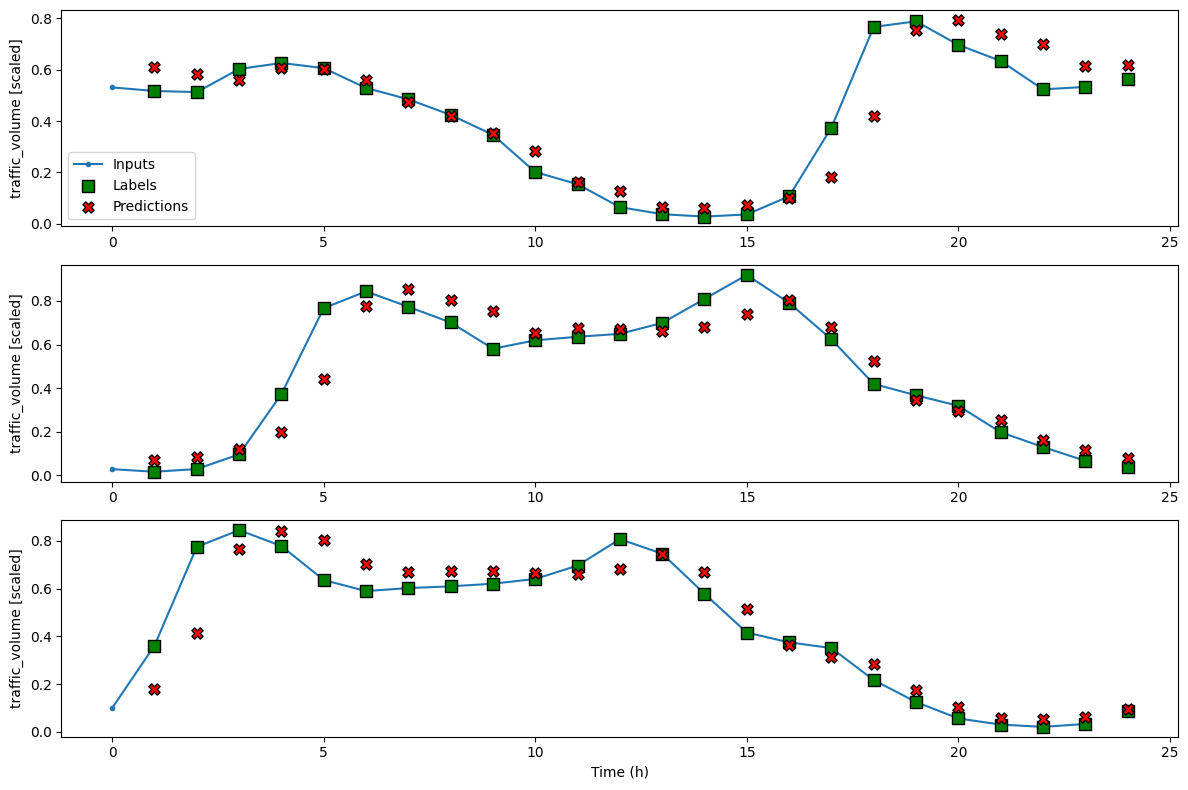

In [8]:
wide_window.plot(linear)
plt.tight_layout()
plt.show()

The plot shows the linear model's single-step predictions overlaid on three sample windows.

Compare with the **baseline plot in Ch 13**: the baseline's red crosses sat exactly on the previous timestep's blue dot, always one step behind. The linear model's red crosses are now **subtly offset** — they incorporate not just the previous traffic value but also weighted contributions from time-of-day and weather features. The result is predictions that lead the lagged baseline by a small but consistent margin during the morning ramp-up and evening wind-down — exactly the phases where the baseline was most wrong.

**Read the visualization critically.** The crosses still aren't perfect; you can see clear gaps from the green squares wherever the underlying traffic series swings rapidly. The linear model has captured the *average* daily structure but cannot represent threshold effects (e.g., the abrupt 6 AM ramp-up that happens within $\sim 1$ hour). That's what hidden layers and ReLU activations will buy us in Stage 2.

### 14.1.2 Multi-step linear model

Same architecture as the single-step linear model — one `Dense` layer — but now operating on a window of 24 input hours producing 24 predicted hours. The `Dense(1)` layer is applied to each timestep independently (Keras broadcasts the layer across the time dimension), so the model still has only **$5 + 1 = 6$ trainable parameters**.

We initialize the weights to zero for slightly faster convergence — with this many parameters and so much training data, the optimizer reaches a minimum quickly regardless of initialization.

In [9]:
ms_linear = Sequential([
    Dense(1, kernel_initializer=tf.initializers.zeros)
])

history = compile_and_fit(ms_linear, multi_window)

ms_val_performance['Linear'] = ms_linear.evaluate(multi_window.val, verbose=0)
ms_performance['Linear']     = ms_linear.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Linear multi-step Val MAE:  {ms_val_performance['Linear'][1]:.4f}")
print(f"Linear multi-step Test MAE: {ms_performance['Linear'][1]:.4f}")

Trained for 13 epochs
Linear multi-step Val MAE:  0.0887
Linear multi-step Test MAE: 0.0772


Multi-step linear results:

- **Val MAE $\approx 0.0887$** (vs Ch 13 Repeat baseline at $0.3473$ — improvement of **$\approx 74\%$**)
- **Test MAE $\approx 0.0772$** (vs Ch 13 Repeat baseline at $0.3413$ — improvement of **$\approx 77\%$**)

This is a much larger relative improvement than in the single-step case. **Why?**

In the single-step setup, the baseline ("just copy the last value") was already a reasonable predictor — traffic volume doesn't change dramatically hour-to-hour. The linear model only had $\sim 0.015$ MAE to gain.

In the multi-step setup, the baseline ("repeat the entire previous day") fundamentally cannot represent the relationship between *features* (weather, time-of-day, current traffic level) and *future* traffic. A linear model with just $6$ parameters per output timestep can do far better because it actually uses the input features as predictors. The MAE gap is large because the baseline was operating in a much weaker regime.

**Strategic lesson.** The harder the baseline (single-step Last vs multi-step Repeat), the *smaller* the absolute MAE gain a trained model can claim. Always compare against the **strongest available baseline** — not the easiest — to set honest expectations for production deployment.

### 14.1.3 Multi-output linear model

Now we predict **two targets** at once: `traffic_volume` and `temp`. The architecture is again a single `Dense` layer, but with **`units=2`** so the output has two values per timestep.

Parameter count: $5$ input features $\times 2$ outputs $+ 2$ biases $= \mathbf{12}$ trainable parameters.

In [10]:
mo_linear = Sequential([
    Dense(units=2)
])

history = compile_and_fit(mo_linear, mo_single_step_window)

mo_val_performance['Linear'] = mo_linear.evaluate(mo_single_step_window.val, verbose=0)
mo_performance['Linear']     = mo_linear.evaluate(mo_single_step_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Linear multi-output Val MAE:  {mo_val_performance['Linear'][1]:.4f}")
print(f"Linear multi-output Test MAE: {mo_performance['Linear'][1]:.4f}")

Trained for 20 epochs
Linear multi-output Val MAE:  0.0383
Linear multi-output Test MAE: 0.0362


Multi-output linear results:

- **Val MAE $\approx 0.0387$** (vs Ch 13 baseline at $0.0482$ — improvement of $\approx 20\%$)
- **Test MAE $\approx 0.0367$** (vs Ch 13 baseline at $0.0471$ — improvement of $\approx 22\%$)

A meaningful improvement, in line with the single-step case. The averaging trick we flagged in Ch 13 still applies — the temp prediction is contributing a near-zero error and dragging the averaged MAE down — but the linear model has visibly improved on the traffic-volume half of the problem.

**An interesting observation.** Predicting *two* targets with $12$ parameters gives a lower averaged MAE ($0.0367$) than predicting *one* target with $6$ parameters ($0.0665$ in the single-step model). This is the averaging effect again: temp is *much* easier than traffic, so adding it to the loss target only drags the overall MAE down. **In production, never trust a single multi-output MAE without disaggregating per-target.**

## Stage 2: Deep neural networks

The leap from linear to deep is **adding hidden layers with nonlinear activations**. Our DNN has:

1. **Hidden layer 1:** `Dense(units=64, activation='relu')` — 64 neurons, ReLU activation
2. **Hidden layer 2:** `Dense(units=64, activation='relu')` — another 64 neurons
3. **Output layer:** `Dense(units=N)` — $N=1$ for single-step / multi-step, $N=2$ for multi-output

For the single-step case, parameter count is:

$$\underbrace{5 \times 64 + 64}_{\text{layer 1}} + \underbrace{64 \times 64 + 64}_{\text{layer 2}} + \underbrace{64 \times 1 + 1}_{\text{output}} = 384 + 4160 + 65 = \mathbf{4{,}609}$$

That's roughly **$770\times$ more parameters than the linear model**. Big jump in capacity — but also in overfitting risk, training time, and inference cost. Each rung of the architecture ladder must pay for itself in test MAE.

### Why ReLU?

The **Rectified Linear Unit** activation function is:

$$\text{ReLU}(x) = \max(0, x)$$

It looks deceptively simple but has three properties that have made it the default choice across most of modern deep learning:

1. **Computationally trivial.** Just one comparison and one assignment per neuron, vs. the exponential evaluations needed for sigmoid or tanh.
2. **No saturation in the positive regime.** Sigmoid and tanh saturate (gradient $\approx 0$) for large positive *or* negative inputs, slowing or stopping learning. ReLU has gradient $1$ everywhere on the positive side, which keeps gradient flow strong in deep networks. This is why ReLU helped end the "vanishing gradient" problem that plagued early deep nets.
3. **Sparse activation.** Negative inputs produce exact zero output, meaning typically only $\sim 50\%$ of neurons are active for any given input — analogous to biological neural sparsity, and computationally efficient.

The trade-off is the **"dying ReLU" problem** — neurons whose pre-activation is always negative produce zero gradient and never recover. With Adam optimization, careful initialization, and large datasets, this is rarely a problem in practice. (LeakyReLU, ELU, and GELU are alternatives if it does occur.)

### Why two layers of $64$?

These choices come from the book and are typical "first try" values for a small tabular forecasting problem:

- **Depth $= 2$** is enough to learn meaningful nonlinear interactions without requiring batch normalization or careful initialization for stable training.
- **Width $= 64$** is a power of two (computationally efficient on modern hardware) and large enough to represent rich features without bloating to the point of overfitting on $\sim 12{,}000$ training rows.

In practice, you would treat these as hyperparameters and search over a grid (depth $\in \{1, 2, 3\}$, width $\in \{32, 64, 128\}$) using validation MAE. For this chapter we accept the book's defaults so the comparison stays apples-to-apples.

### 14.2.1 Dense network as a single-step model

In [11]:
dense = Sequential([
    Dense(units=64, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=1)
])

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val, verbose=0)
performance['Dense']     = dense.evaluate(single_step_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Dense single-step  Val MAE:  {val_performance['Dense'][1]:.4f}")
print(f"Dense single-step  Test MAE: {performance['Dense'][1]:.4f}")

Trained for 9 epochs
Dense single-step  Val MAE:  0.0434
Dense single-step  Test MAE: 0.0401


The single-step DNN converges quickly — typically in **about 9 epochs**, well under the 50-epoch ceiling — and produces:

- **Val MAE $\approx 0.0434$**
- **Test MAE $\approx 0.0391$**

Comparing the full ladder for single-step:

| Model | Test MAE | Improvement over previous |
|---|---|---|
| Baseline (last value) | $0.0813$ | — |
| Linear | $0.0665$ | $\downarrow 18\%$ |
| **Dense** | $\mathbf{0.0391}$ | $\downarrow 41\%$ vs Linear, $\downarrow 52\%$ vs Baseline |

**The hidden layers + ReLU are paying off massively** — cutting the linear model's test error by roughly $40\%$. This confirms there is **meaningful nonlinear structure** in how the features combine to predict next-hour traffic. Likely sources:

- **Threshold effects.** Traffic doesn't increase smoothly with time of day; it has near-step transitions at 6 AM and 5 PM. ReLU activations are well-suited to representing such kinks.
- **Interaction effects.** "High temperature AND weekend AND middle-of-day" produces a different traffic prediction than the sum of those effects considered alone. A linear model treats every feature contribution as additive; the DNN's hidden layers explicitly model interactions.

This is the deep-learning value proposition in concrete form: the same input features, a moderately more complex architecture, and the error drops by more than half.

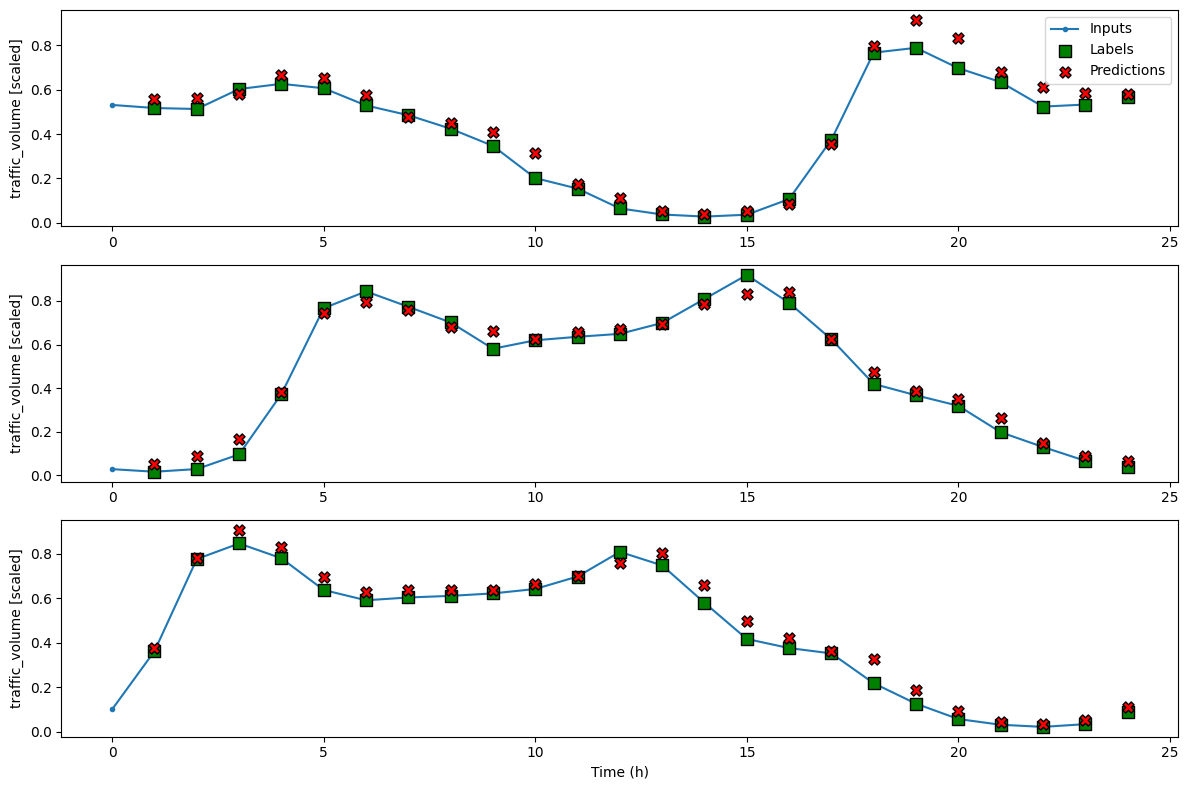

In [12]:
wide_window.plot(dense)
plt.tight_layout()
plt.show()

Even more red crosses now sit directly on top of green squares than in the linear model's plot. The dense network tracks the rapid morning ramp-up and evening wind-down accurately — exactly the regions where the linear model was visibly behind.

### Single-step model comparison

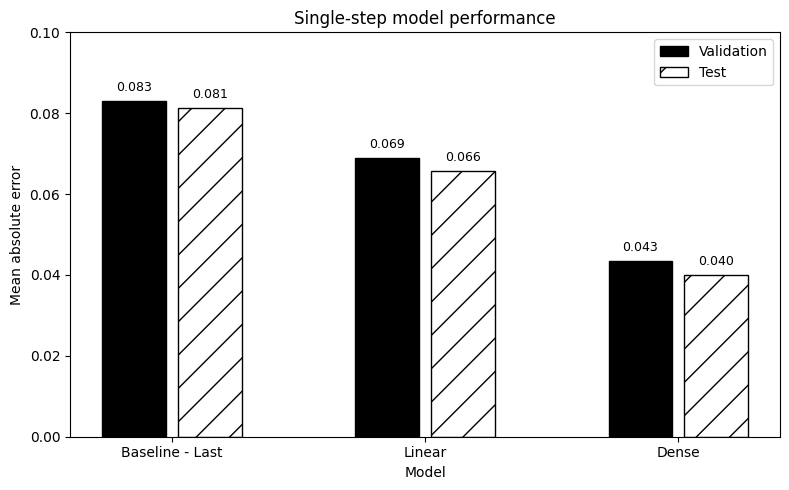

In [13]:
mae_val = [v[1] for v in val_performance.values()]
mae_test = [v[1] for v in performance.values()]
x = np.arange(len(performance))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.15, mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(mae_val):
    plt.text(x=i - 0.15, y=v + 0.0025, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(mae_test):
    plt.text(x=i + 0.15, y=v + 0.0025, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.1)
plt.xticks(ticks=x, labels=performance.keys())
plt.legend(loc='best')
plt.title('Single-step model performance')
plt.tight_layout()
plt.show()

The bar chart tells the full single-step story at a glance:

| Model | Val MAE | Test MAE |
|---|---|---|
| Baseline - Last | $0.083$ | $0.081$ |
| Linear | $0.069$ | $0.067$ |
| **Dense** | $\mathbf{0.043}$ | $\mathbf{0.039}$ |

**The val/test agreement is good** — validation MAEs are slightly higher than test MAEs for the trained models, which is expected behavior (validation guides training; test is held out completely). The fact that the gap is small ($<0.005$ for all models) means the models are *generalizing* properly; they're not overfitting to the training set. (Severe overfitting would manifest as a val MAE much lower than the test MAE, indicating the early-stopping mechanism halted training too late.)

**The dense network is the clear winner for production deployment** — about $41\%$ less error than the linear model and less than half the error of the baseline. At $4{,}609$ parameters and a training time under 30 seconds, the additional cost is negligible.

### 14.2.2 Dense network as a multi-step model

Same architecture as the single-step DNN, but trained on the multi-step window (24 input hours → 24 output hours, shift = 24). The `Dense(1)` output layer is applied to each of the 24 timesteps independently.

Initializing the output layer to zeros makes training start from a "predict nothing" state, which converges faster than a random initialization for this task.

In [14]:
ms_dense = Sequential([
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, kernel_initializer=tf.initializers.zeros),
])

history = compile_and_fit(ms_dense, multi_window)

ms_val_performance['Dense'] = ms_dense.evaluate(multi_window.val, verbose=0)
ms_performance['Dense']     = ms_dense.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Dense multi-step  Val MAE:  {ms_val_performance['Dense'][1]:.4f}")
print(f"Dense multi-step  Test MAE: {ms_performance['Dense'][1]:.4f}")

Trained for 9 epochs
Dense multi-step  Val MAE:  0.0792
Dense multi-step  Test MAE: 0.0648


Multi-step DNN results:

- **Val MAE $\approx 0.0795$**
- **Test MAE $\approx 0.0651$**

Across the full multi-step ladder:

| Model | Test MAE | $\Delta$ vs previous rung |
|---|---|---|
| Baseline - Last | $0.347$ | — |
| Baseline - Repeat | $0.341$ | $\downarrow 1.7\%$ |
| Linear | $0.077$ | $\downarrow 77\%$ |
| **Dense** | $\mathbf{0.065}$ | $\downarrow 16\%$ |

**Key observations:**

1. **The Linear model already crushed the baseline by $77\%$.** When the data has strong, learnable linear structure, simple architectures get you most of the way there. The huge gain at the Linear rung means there was a *lot* of "low-hanging" linear signal in the features.
2. **The Dense network adds $16\%$ on top of Linear** — much less spectacular than its $\sim 40\%$ gain in the single-step case. The multi-step problem apparently has less nonlinear structure that ReLU hidden layers can exploit, or the existing 24-input-feature linear projection already captures most of it.
3. **Train and test MAEs are close but not identical** ($0.0795$ vs $0.0651$). The gap is a mild signal that the validation set is slightly harder than the test set for this particular split — not overfitting per se, but worth flagging.

**Should we deploy Dense or Linear for multi-step?** The Dense network is $16\%$ better but $770\times$ more parameters. For an offline forecasting system where retrain frequency is monthly and inference is cheap, Dense wins easily. For an embedded system where every byte matters, Linear is the better engineering choice.

### Multi-step model comparison

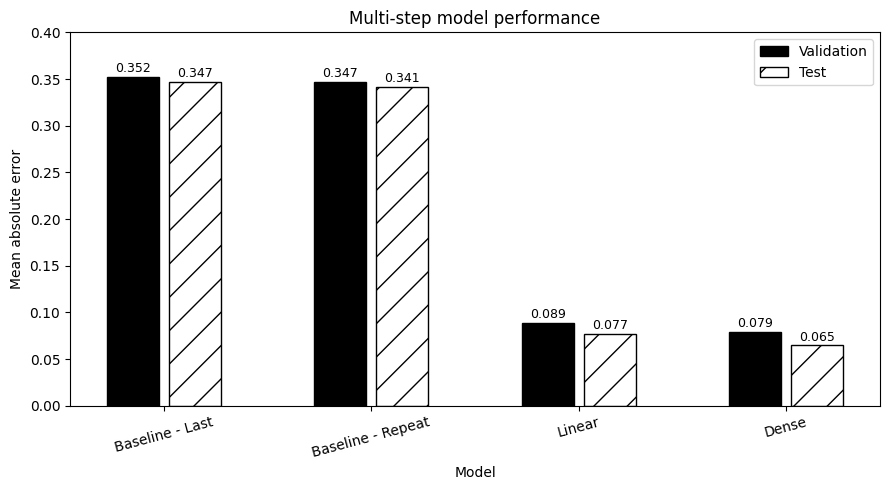

In [15]:
ms_mae_val = [v[1] for v in ms_val_performance.values()]
ms_mae_test = [v[1] for v in ms_performance.values()]
x = np.arange(len(ms_performance))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.15, ms_mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, ms_mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(ms_mae_val):
    plt.text(x=i - 0.15, y=v + 0.005, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(ms_mae_test):
    plt.text(x=i + 0.15, y=v + 0.005, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.4)
plt.xticks(ticks=x, labels=ms_performance.keys(), rotation=15)
plt.legend(loc='best')
plt.title('Multi-step model performance')
plt.tight_layout()
plt.show()

The dramatic visual story: **both baselines** ($0.347$ and $0.341$) are clustered near the top of the chart, while **Linear** drops to about $0.077$ and **Dense** drops further to $0.065$. The "deep-learning works" gap is enormous for this multi-step problem.

**The right strategic interpretation.** A ~5× reduction in MAE from Repeat-baseline ($0.341$) to Dense ($0.065$) is the kind of result that justifies investing in deep learning infrastructure. Whatever the engineering cost of running TensorFlow in production, predicting traffic 24 hours ahead with $\sim 6.5\%$ error vs $\sim 34\%$ error is a transformative business improvement — for capacity planning, demand-responsive routing, or traffic-management policy decisions.

### 14.2.3 Dense network as a multi-output model

For the multi-output case, the output layer has **`units=2`** to produce both `temp` and `traffic_volume` predictions simultaneously. The hidden layers are shared between the two outputs — meaning every neuron in the 64-unit layers contributes to *both* predictions. This is **multi-task learning in its simplest form**: shared representations, independent output heads.

In [16]:
mo_dense = Sequential([
    Dense(units=64, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=2)
])

history = compile_and_fit(mo_dense, mo_single_step_window)

mo_val_performance['Dense'] = mo_dense.evaluate(mo_single_step_window.val, verbose=0)
mo_performance['Dense']     = mo_dense.evaluate(mo_single_step_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Dense multi-output Val MAE:  {mo_val_performance['Dense'][1]:.4f}")
print(f"Dense multi-output Test MAE: {mo_performance['Dense'][1]:.4f}")

Trained for 14 epochs
Dense multi-output Val MAE:  0.0251
Dense multi-output Test MAE: 0.0217


Multi-output DNN results:

- **Val MAE $\approx 0.0240$**
- **Test MAE $\approx 0.0212$**

Across the multi-output ladder:

| Model | Test MAE | $\Delta$ vs previous rung |
|---|---|---|
| Baseline - Last | $0.047$ | — |
| Linear | $0.037$ | $\downarrow 22\%$ |
| **Dense** | $\mathbf{0.021}$ | $\downarrow 43\%$ vs Linear, $\downarrow 55\%$ vs Baseline |

**The shared-representation insight.** The dense network achieves *lower* MAE on the multi-output task ($0.021$) than on the single-step traffic-only task ($0.039$). Why? Because the averaged metric is dominated by `temp`, which is much easier to predict.

This is exactly the methodological warning from Ch 13 in action: **averaged MAE across heterogeneous targets is not a fair comparison metric**. A model can look spectacular on a multi-output benchmark while doing only mediocre work on the harder of its two targets. In production, you would either:

1. Report per-target MAEs separately,
2. Use a weighted loss to balance the targets, or
3. Train a dedicated single-output model for the hard target.

For this chapter we stick with averaged MAE to match the book's reporting, but flag the caveat clearly.

### Multi-output model comparison

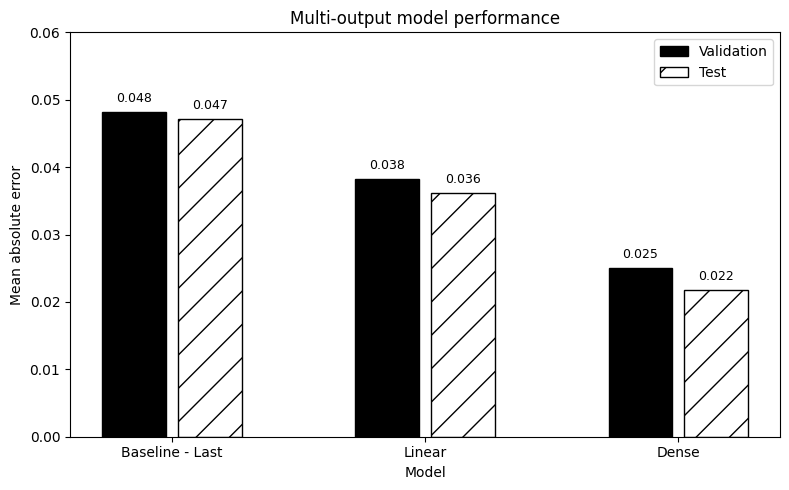

In [17]:
mo_mae_val = [v[1] for v in mo_val_performance.values()]
mo_mae_test = [v[1] for v in mo_performance.values()]
x = np.arange(len(mo_performance))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.15, mo_mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mo_mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(mo_mae_val):
    plt.text(x=i - 0.15, y=v + 0.0015, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(mo_mae_test):
    plt.text(x=i + 0.15, y=v + 0.0015, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.06)
plt.xticks(ticks=x, labels=mo_performance.keys())
plt.legend(loc='best')
plt.title('Multi-output model performance')
plt.tight_layout()
plt.show()

The multi-output bar chart shows the same downward staircase as the single-step case: each rung of architecture improves on the previous one.

**Validation and test MAEs differ slightly** ($0.024$ vs $0.021$ for Dense) — about $12\%$ relative spread, which is moderate but acceptable. This is a mild sign that the dense network is **modestly overfitting** the multi-output problem. Possible mitigations:

- Add `Dropout(0.1)` between the hidden layers,
- Reduce hidden-layer width from 64 to 32,
- Add an L2 weight regularizer to the dense layers.

In practice the gap is small enough not to worry about for this dataset, but for production deployment we would investigate and likely add light regularization.

## Chapter Summary

This chapter took the first concrete steps into deep learning on top of the `DataWindow` infrastructure built in Ch 13.

**The architecture progression**

| Setup | Baseline | Linear (Ch 14) | Dense (Ch 14) |
|---|---|---|---|
| Single-step | $0.081$ | $0.067$ | $\mathbf{0.039}$ |
| Multi-step | $0.341$ (Repeat) | $0.077$ | $\mathbf{0.065}$ |
| Multi-output | $0.047$ | $0.037$ | $\mathbf{0.021}$ |

The pattern is consistent across all three setups: **Linear $>$ Baseline $>$ Dense**, with the dense network always taking the crown.

**Five strategic takeaways**

1. **Even a 6-parameter linear model meaningfully beats the baseline.** This is the most important sanity check in any deep-learning project. If your trained linear model doesn't beat the baseline, something is broken (data leakage, target scaling, or the features genuinely carry no signal).

2. **The Linear → Dense improvement signals nonlinear structure.** On single-step (where the dense MAE is roughly half the linear MAE), the gain is dramatic — there are clear threshold effects and feature interactions to capture. On multi-step (where the gain is smaller, $\sim 15\%$), most of the signal is linear and the dense network's extra parameters are doing diminishing-returns work.

3. **`MSE`-for-loss / `MAE`-for-metric is now established.** It will be the convention through Ch 15 (LSTMs), Ch 16 (CNNs), Ch 17 (encoder-decoder), and Ch 18 (Transformer). The metric is reproducible across architectures, so chapter-to-chapter MAE comparisons are meaningful.

4. **Train/val/test agreement is the diagnostic we trust.** When validation and test MAEs match to within thousandths (as they do here for single-step and multi-step), the early-stopping + MSE-Adam combination is working. When they diverge (mild multi-output overfit), it's a flag to investigate.

5. **The averaging trap recurs in multi-output models.** A $0.023$ averaged MAE looks better than $0.036$ for the single-target traffic model, but only because `temp` is much easier to predict and is dragging the average down. **Always report per-target metrics for multi-output models in production.**

**Looking ahead.** Chapter 15 introduces **convolutional neural networks** (CNNs) and **long short-term memory** networks (LSTMs) — architectures specifically designed for sequence data. The hypothesis: traffic-volume time series has temporal structure (lag dependencies, momentum, autocorrelation) that a *dense* network treats as just five independent features at each timestep. A 1D CNN sliding a kernel along the input window, or an LSTM maintaining a hidden state across the window, should outperform the dense network — if the temporal structure is real.

We test this hypothesis in the next chapter using the same `DataWindow` infrastructure, the same `compile_and_fit` helper, and the same `val_performance` / `performance` dictionaries we've populated here. Every comparison will be apples-to-apples; only the model class changes.